        Date Product ID  Units Sold  Inventory Level Weather Condition  Holiday/Promotion
0 2022-01-01      P0001         127              231             Rainy                  0
1 2022-01-01      P0002         150              204             Sunny                  0
2 2022-01-01      P0003          65              102             Sunny                  1
[RED] P0001  MAE(base)=69.6  MAE(weather)=70.5  Days until stockout=1.8
[RED] P0002  MAE(base)=79.8  MAE(weather)=78.8  Days until stockout=2.7
[RED] P0003  MAE(base)=97.3  MAE(weather)=98.0  Days until stockout=0.5
[RED] P0004  MAE(base)=85.3  MAE(weather)=85.4  Days until stockout=2.1
[WARNING] P0005  MAE(base)=91.9  MAE(weather)=90.4  Days until stockout=3.1
[RED] P0006  MAE(base)=82.9  MAE(weather)=83.7  Days until stockout=2.3
[RED] P0007  MAE(base)=93.1  MAE(weather)=92.8  Days until stockout=1.9
[RED] P0008  MAE(base)=65.6  MAE(weather)=63.8  Days until stockout=2.5
[RED] P0009  MAE(base)=75.9  MAE(weather)=76.9  Days until s

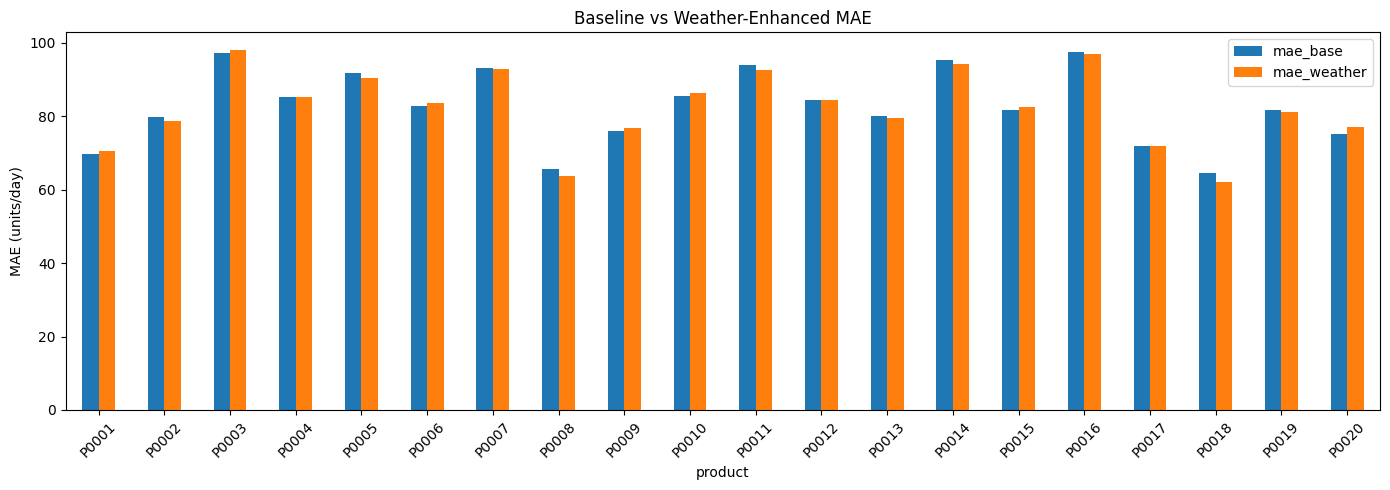

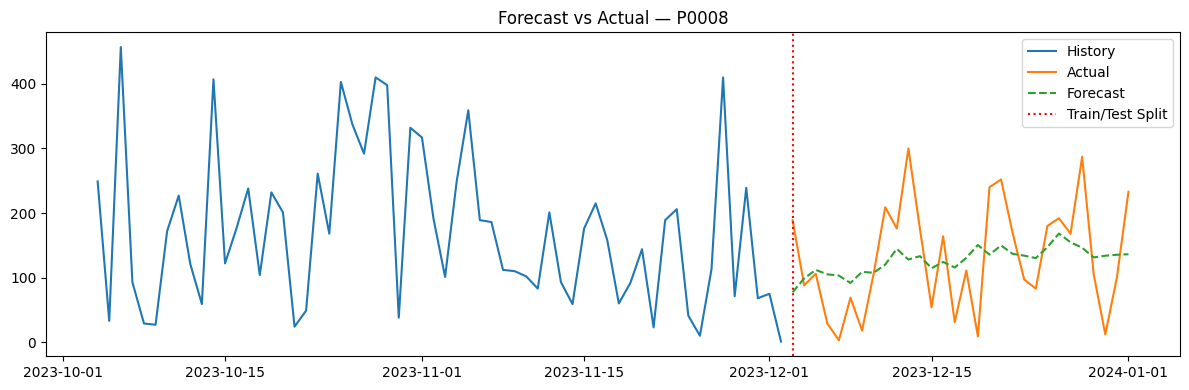

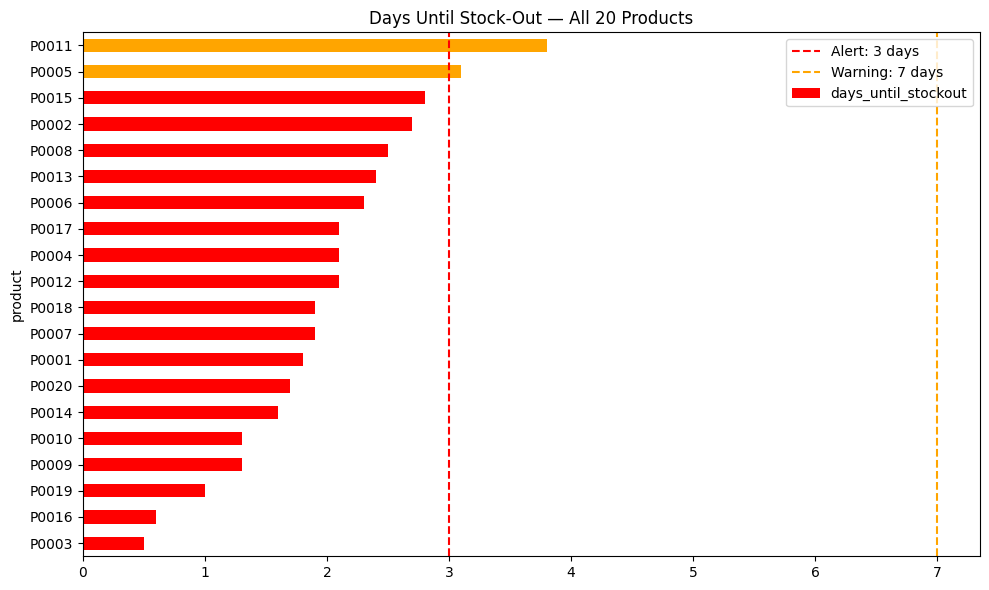


  Cold Start Solution (New Products)
Average daily sales by category (used for new products):
Category
Clothing       134.35
Electronics    133.26
Furniture      135.58
Groceries      136.84
Toys           135.66

  Similar Products (Collaborative Forecasting)
Top 3 most similar product pairs:
Product ID  Product ID
P0007       P0001         0.072732
P0008       P0012         0.072150
P0015       P0012         0.069522

Done! 3 charts saved: mae_comparison.png / forecast_plot.png / stockout_chart.png


In [5]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")


# 1. Load & Clean Data

df = pd.read_csv("retail_store_inventory.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Store ID'] == 'S001'].copy()

weather_map = {"Sunny": 0, "Cloudy": 1, "Rainy": 2, "Snowy": 3}
df['weather_code'] = df['Weather Condition'].map(weather_map).fillna(0)
df['is_rain'] = df['Weather Condition'].isin(['Rainy', 'Snowy']).astype(int)
df = df.dropna(subset=['Units Sold'])
df = df[df['Units Sold'] >= 0]

print(df[['Date','Product ID','Units Sold','Inventory Level',
          'Weather Condition','Holiday/Promotion']].head(3).to_string())


# 2. Prepare Prophet Format

def prepare_prophet(df_product):
    df_p = df_product[['Date', 'Units Sold', 'weather_code',
                        'is_rain', 'Holiday/Promotion']].copy()
    df_p = df_p.rename(columns={
        'Date':               'ds',
        'Units Sold':         'y',
        'Holiday/Promotion':  'is_holiday'
    })
    return df_p.sort_values('ds').reset_index(drop=True)


# 3. Run for ALL 20 Products

products = df['Product ID'].unique()
results  = []

for product_name in products:
    df_p = df[df['Product ID'] == product_name]
    data = prepare_prophet(df_p)

    # Edge case 1: Not enough history → use moving average
    if len(data) < 14:
        avg_demand = data['y'].tail(7).mean()
        stock = df_p['Inventory Level'].iloc[-1]
        days  = round(stock / avg_demand, 1) if avg_demand > 0 else 999
        results.append({'product': product_name, 'method': 'moving_avg',
                        'mae_base': None, 'rmse_base': None,
                        'mae_weather': None, 'rmse_weather': None,
                        'days_until_stockout': days, 'current_stock': stock})
        print(f"Warning: {product_name}: not enough data, using moving average, days until stockout={days}")
        continue

    # Edge case 2: Zero sales in last 7 days → skip
    if data['y'].tail(7).sum() == 0:
        print(f"Skipped: {product_name}: low movement, excluded from alerts")
        continue

    # Train/test split (last 30 days for testing)
    train = data.iloc[:-30]
    test  = data.iloc[-30:]


    # 4. Baseline Model (no weather)

    model_base = Prophet(weekly_seasonality=True, yearly_seasonality=True,
                         daily_seasonality=False)
    model_base.fit(train[['ds', 'y']])
    future_base   = model_base.make_future_dataframe(periods=30)
    forecast_base = model_base.predict(future_base)
    pred_base     = forecast_base['yhat'].tail(30).clip(lower=0).values


    # 5. Weather-Enhanced Model

    model_weather = Prophet(weekly_seasonality=True, yearly_seasonality=True,
                            daily_seasonality=False, changepoint_prior_scale=0.05)
    model_weather.add_regressor('weather_code')
    model_weather.add_regressor('is_rain')
    model_weather.add_regressor('is_holiday')
    model_weather.fit(train)

    future_w         = test[['ds', 'weather_code', 'is_rain', 'is_holiday']].copy()
    forecast_weather = model_weather.predict(future_w)
    pred_weather     = forecast_weather['yhat'].clip(lower=0).values


    # 6. Evaluation (MAE & RMSE)

    y_true    = test['y'].values
    mae_base  = mean_absolute_error(y_true, pred_base)
    rmse_base = np.sqrt(mean_squared_error(y_true, pred_base))
    mae_w     = mean_absolute_error(y_true, pred_weather)
    rmse_w    = np.sqrt(mean_squared_error(y_true, pred_weather))


    # 7. Stock-out Prediction
    # Current stock divided by average predicted daily demand

    current_stock       = df_p['Inventory Level'].iloc[-1]
    avg_daily_demand    = np.mean(pred_weather)
    days_until_stockout = round(current_stock / avg_daily_demand, 1) if avg_daily_demand > 0 else 999

    results.append({
        'product':            product_name,
        'method':             'prophet+weather',
        'mae_base':           round(mae_base, 2),
        'rmse_base':          round(rmse_base, 2),
        'mae_weather':        round(mae_w, 2),
        'rmse_weather':       round(rmse_w, 2),
        'days_until_stockout': days_until_stockout,
        'current_stock':      current_stock,
    })

    icon = "RED" if days_until_stockout <= 3 else ("WARNING" if days_until_stockout <= 7 else "OK")
    print(f"[{icon}] {product_name}  MAE(base)={mae_base:.1f}  MAE(weather)={mae_w:.1f}  Days until stockout={days_until_stockout}")


# 8. Summary Table

results_df = pd.DataFrame(results)
print("\n" + "="*55)
print("  Summary Results")
print("="*55)
print(results_df[['product','mae_weather','rmse_weather','days_until_stockout']].to_string(index=False))

# 9. Visualizations (3 charts)


# Chart 1: MAE Comparison
results_df.plot(x='product', y=['mae_base','mae_weather'], kind='bar', figsize=(14,5))
plt.title('Baseline vs Weather-Enhanced MAE')
plt.ylabel('MAE (units/day)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('mae_comparison.png', dpi=150)
plt.show()

# Chart 2: Forecast vs Actual for P0008
prod = 'P0008'
d = df[df['Product ID']==prod].copy()
d = d.rename(columns={'Date':'ds','Units Sold':'y','Holiday/Promotion':'is_holiday'}).sort_values('ds')
d = d[['ds','y','weather_code','is_rain','is_holiday']]
train, test = d.iloc[:-30], d.iloc[-30:]

m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
for reg in ['weather_code','is_rain','is_holiday']:
    m.add_regressor(reg)
m.fit(train)
fc = m.predict(test[['ds','weather_code','is_rain','is_holiday']])

plt.figure(figsize=(12,4))
plt.plot(train['ds'].tail(60), train['y'].tail(60), label='History')
plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(fc['ds'], fc['yhat'].clip(0), '--', label='Forecast')
plt.axvline(test['ds'].iloc[0], color='red', linestyle=':', label='Train/Test Split')
plt.legend()
plt.title(f'Forecast vs Actual — {prod}')
plt.tight_layout()
plt.savefig('forecast_plot.png', dpi=150)
plt.show()

# Chart 3: Days Until Stock-Out
d3 = results_df.sort_values('days_until_stockout')
colors = ['red' if v<=3 else 'orange' if v<=7 else 'green' for v in d3['days_until_stockout']]
d3.plot(x='product', y='days_until_stockout', kind='barh',
        color=colors, figsize=(10,6), legend=False)
plt.axvline(3, color='red', linestyle='--', label='Alert: 3 days')
plt.axvline(7, color='orange', linestyle='--', label='Warning: 7 days')
plt.legend()
plt.title('Days Until Stock-Out — All 20 Products')
plt.tight_layout()
plt.savefig('stockout_chart.png', dpi=150)
plt.show()


# 10. Extra Feature: Cold Start Solution
# For new products with no sales history,
# use category-level average as estimate

print("\n" + "="*55)
print("  Cold Start Solution (New Products)")
print("="*55)
category_avg = df.groupby('Category')['Units Sold'].mean().round(2)
print("Average daily sales by category (used for new products):")
print(category_avg.to_string())


# 11. Extra Feature: Similar Products
# Use correlation to find similar products
# for collaborative forecasting

print("\n" + "="*55)
print("  Similar Products (Collaborative Forecasting)")
print("="*55)
product_corr = df.pivot_table(index='Date', columns='Product ID', values='Units Sold').corr()
print("Top 3 most similar product pairs:")
corr_pairs = product_corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(corr_pairs.head(3).to_string())

print("\nDone! 3 charts saved: mae_comparison.png / forecast_plot.png / stockout_chart.png")